In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (78, 2)
Test shape: (20, 2)


,text,sentiment
0,samsung phone way better galaxy z fold mature ...,positive
1,im confused oppo v iphone oppo better photo b...,neutral
2,iphone samsung day time want better android ge...,neutral
3,specific speciality people would pick android ...,neutral
4,crazy much nicer android use io better notific...,positive


In [5]:
X_train = train['text']
y_train = train['sentiment']

X_test = test['text']
y_test = test['sentiment']

## TF-IDF VECTORIZATION

In [8]:
vectorizer = TfidfVectorizer(
    max_features=5000,     # improves performance
    ngram_range=(1,2)      # unigrams + bigrams (important)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorization complete ✅")

Vectorization complete ✅


In [10]:
model = SVC(
    kernel='linear',   # best for text classification
    C=1.0
)

model.fit(X_train_vec, y_train)

print("SVM model trained ✅")

SVM model trained ✅


In [12]:
y_pred = model.predict(X_test_vec)
y_pred

array(['negative', 'positive', 'positive', 'positive', 'neutral',
       'positive', 'positive', 'positive', 'positive', 'neutral',
       'positive', 'negative', 'positive', 'positive', 'neutral',
       'positive', 'positive', 'negative', 'neutral', 'positive'],
      dtype=object)

## Evaluation Metrics

In [15]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(report)

Accuracy: 0.55
Precision: 0.519551282051282
Recall: 0.55
F1 Score: 0.5033333333333333

Classification Report:

              precision    recall  f1-score   support

    negative       0.33      0.14      0.20         7
     neutral       0.75      0.60      0.67         5
    positive       0.54      0.88      0.67         8

    accuracy                           0.55        20
   macro avg       0.54      0.54      0.51        20
weighted avg       0.52      0.55      0.50        20



## CONFUSION MATRIX

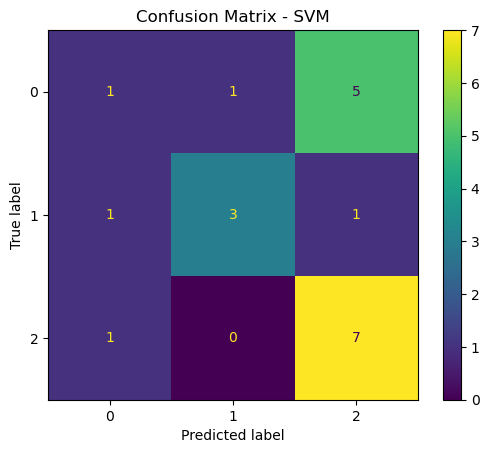

In [18]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - SVM")

plt.savefig("../visuals/07_svm_confusion_matrix.png")

plt.show()

## Metrics Bar Chart

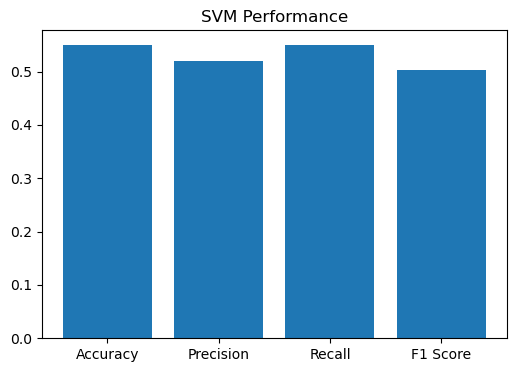

In [24]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)

plt.title("SVM Performance")

plt.savefig("../visuals/08_svm_metrics.png")

plt.show()

In [26]:
with open("../results/svm_results.txt", "w") as f:
    f.write("SVM Results\n")
    f.write("====================\n\n")
    
    f.write(f"Accuracy: {accuracy}\n")
    f.write(f"Precision: {precision}\n")
    f.write(f"Recall: {recall}\n")
    f.write(f"F1 Score: {f1}\n\n")
    
    f.write("Classification Report:\n")
    f.write(report)

print("Results saved in results folder ✅")

Results saved in results folder ✅
